# 📈 Stock Market Prediction Calibration Analysis
This Jupyter Notebook performs a statistical evaluation of historical long-term stock market return predictions from major financial organizations (Vanguard, J.P. Morgan, GMO, AQR, BlackRock, and Jack Bogle) against actual realized S&P 500 total returns.

### Objectives:
1. **Calibration**: Test if forecasted returns correlate with actual realized returns or if the relationship is random.
2. **OLS Regression**: Fit a linear model to analyze the trend line of actual returns vs. predicted midpoints.
3. **Pessimism / Bias Check**: Compute prediction errors (MAE, RMSE) and mean forecast bias to check if Wall Street predictions are systematically conservative or optimistic.
4. **Visualizations**: Generate both a calibration plot (scatter with regression line) and a comparison plot of realized returns against predicted ranges.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

In [2]:
# Load results
with open('results.json', 'r') as f:
    data = json.load(f)

# Filter for elapsed predictions (those that have fully completed)
elapsed = [p for p in data if p.get('is_elapsed')]
print(f"Loaded {len(elapsed)} completed predictions for statistical analysis.")

Loaded 34 completed predictions for statistical analysis.


In [3]:
# Extract prediction midpoints and actual realized CAGRs
predicted = np.array([sum(p['predicted_range']) / 2.0 for p in elapsed])
actual = np.array([p['actual_return'] for p in elapsed])
n = len(elapsed)

# Pearson correlation (r)
mean_p = np.mean(predicted)
mean_a = np.mean(actual)
cov = np.sum((predicted - mean_p) * (actual - mean_a))
var_p = np.sum((predicted - mean_p) ** 2)
var_a = np.sum((actual - mean_a) ** 2)
pearson_r = cov / math.sqrt(var_p * var_a)

# Student's t test for Pearson r (two-tailed p-value)
t_stat = pearson_r * math.sqrt((n - 2) / (1 - pearson_r**2))
# Numerical CDF approximation of t-distribution
def t_pdf(u, df):
    coeff = math.gamma((df + 1) / 2) / (math.sqrt(df * math.pi) * math.gamma(df / 2))
    return coeff * (1 + (u**2) / df) ** (- (df + 1) / 2)

steps = 1000
lower = abs(t_stat)
upper = max(10.0, lower + 5.0)
h = (upper - lower) / steps
integral = 0.5 * (t_pdf(lower, n-2) + t_pdf(upper, n-2))
for i in range(1, steps):
    integral += t_pdf(lower + i * h, n-2)
pearson_p = min(1.0, 2.0 * integral * h)

# OLS Regression
comb_slope = cov / var_p
comb_intercept = mean_a - comb_slope * mean_p
comb_r_squared = pearson_r ** 2

# Forecast errors
errors = actual - predicted
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors ** 2))
mean_bias = np.mean(errors)


In [4]:
# Calculate Pearson correlation and OLS Regression
# We will calculate for Combined, Nominal-Only, and Real-Only independently.

def calculate_stats_subset(predicted_sub, actual_sub):
    n_sub = len(predicted_sub)
    if n_sub < 3:
        return None
    mean_p = np.mean(predicted_sub)
    mean_a = np.mean(actual_sub)
    cov = np.sum((predicted_sub - mean_p) * (actual_sub - mean_a))
    var_p = np.sum((predicted_sub - mean_p) ** 2)
    var_a = np.sum((actual_sub - mean_a) ** 2)
    
    if var_p == 0 or var_a == 0:
        return None
        
    r = cov / math.sqrt(var_p * var_a)
    
    # p-value using t approximation
    t_stat = r * math.sqrt((n_sub - 2) / (1 - r**2))
    def t_pdf(u, df):
        coeff = math.gamma((df + 1) / 2) / (math.sqrt(df * math.pi) * math.gamma(df / 2))
        return coeff * (1 + (u**2) / df) ** (- (df + 1) / 2)
    steps = 1000
    lower = abs(t_stat)
    upper = max(10.0, lower + 5.0)
    h = (upper - lower) / steps
    integral = 0.5 * (t_pdf(lower, n_sub-2) + t_pdf(upper, n_sub-2))
    for i in range(1, steps):
        integral += t_pdf(lower + i * h, n_sub-2)
    p_val = min(1.0, 2.0 * integral * h)
    
    slope = cov / var_p
    intercept = mean_a - slope * mean_p
    r_squared = r ** 2
    
    errors_sub = actual_sub - predicted_sub
    mae = np.mean(np.abs(errors_sub))
    rmse = np.sqrt(np.mean(errors_sub ** 2))
    bias = np.mean(errors_sub)
    
    return {
        'n': n_sub, 'r': r, 'p': p_val, 'slope': slope, 'intercept': intercept,
        'r_squared': r_squared, 'mae': mae, 'rmse': rmse, 'bias': bias
    }

# Combined Stats
comb = calculate_stats_subset(predicted, actual)

# Nominal Stats
nominal_indices = [i for i, p in enumerate(elapsed) if p['return_type'] == 'nominal']
nom = calculate_stats_subset(predicted[nominal_indices], actual[nominal_indices])

# Real Stats
real_indices = [i for i, p in enumerate(elapsed) if p['return_type'] == 'real']
real = calculate_stats_subset(predicted[real_indices], actual[real_indices])

print("===============================================")
print("📊 STATISTICAL EVALUATION RESULTS")
print(f"   Number of evaluated predictions: {n}")
print("===============================================")
if comb:
    print("COMBINED VIEW:")
    print(f" Pearson Correlation (r):  {comb['r']:.4f}")
    print(f"   p-value:                {comb['p']:.6f} ({'Significant' if comb['p'] < 0.05 else 'Not Significant'} at 5% level)")
    print(f" Formula:                  Actual = {comb['slope']:.4f} * Predicted + {comb['intercept']:.4f}%")
    print(f" R-squared (R²):           {comb['r_squared']:.4f}")
    print(f" MAE / Mean Bias:          {comb['mae']:.2f} pp / {comb['bias']:+.2f} pp")
print("-----------------------------------------------")
if nom:
    print("NOMINAL PREDICTIONS ONLY:")
    print(f" n:                        {nom['n']}")
    print(f" Pearson Correlation (r):  {nom['r']:.4f}")
    print(f"   p-value:                {nom['p']:.6f} ({'Significant' if nom['p'] < 0.05 else 'Not Significant'} at 5% level)")
    print(f" Formula:                  Actual = {nom['slope']:.4f} * Predicted + {nom['intercept']:.4f}%")
    print(f" R-squared (R²):           {nom['r_squared']:.4f}")
    print(f" MAE / Mean Bias:          {nom['mae']:.2f} pp / {nom['bias']:+.2f} pp")
print("-----------------------------------------------")
if real:
    print("REAL PREDICTIONS ONLY (Inflation-Adjusted):")
    print(f" n:                        {real['n']}")
    print(f" Pearson Correlation (r):  {real['r']:.4f}")
    print(f"   p-value:                {real['p']:.6f} ({'Significant' if real['p'] < 0.05 else 'Not Significant'} at 5% level)")
    print(f" Formula:                  Actual = {real['slope']:.4f} * Predicted + {real['intercept']:.4f}%")
    print(f" R-squared (R²):           {real['r_squared']:.4f}")
    print(f" MAE / Mean Bias:          {real['mae']:.2f} pp / {real['bias']:+.2f} pp")
print("===============================================")

📊 STATISTICAL EVALUATION RESULTS
   Number of evaluated predictions: 34
COMBINED VIEW:
 Pearson Correlation (r):  0.4205
   p-value:                0.013286 (Significant at 5% level)
 Formula:                  Actual = 0.6108 * Predicted + 7.6459%
 R-squared (R²):           0.1768
 MAE / Mean Bias:          6.98 pp / +5.97 pp
-----------------------------------------------
NOMINAL PREDICTIONS ONLY:
 n:                        21
 Pearson Correlation (r):  -0.2119
   p-value:                0.356365 (Not Significant at 5% level)
 Formula:                  Actual = -0.6242 * Predicted + 16.4344%
 R-squared (R²):           0.0449
 MAE / Mean Bias:          6.16 pp / +5.05 pp
-----------------------------------------------
REAL PREDICTIONS ONLY (Inflation-Adjusted):
 n:                        13
 Pearson Correlation (r):  0.4110
   p-value:                0.162952 (Not Significant at 5% level)
 Formula:                  Actual = 1.1133 * Predicted + 7.4527%
 R-squared (R²):           0.1689

In [5]:
# Create summary dataframe
df = pd.DataFrame({
    'Prediction ID': [p['id'] for p in elapsed],
    'Organization': [p['organization'] for p in elapsed],
    'Start Date': [p['source_date'] for p in elapsed],
    'End Date': [p['end_date'] for p in elapsed],
    'Return Type': [p['return_type'] for p in elapsed],
    'Predicted Midpoint (%)': predicted,
    'Actual Return (CAGR %)': actual,
    'Forecast Error (pp)': errors
})
df.sort_values(by='Start Date', inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Prediction ID,Organization,Start Date,End Date,Return Type,Predicted Midpoint (%),Actual Return (CAGR %),Forecast Error (pp)
0,gmo-2000-us-large-cap-7y,GMO,2000-01-31,2007-01-31,real,-1.90,-0.523056,1.376944
1,bogle-2000-us-equities-10y,Jack Bogle,2000-06-30,2010-06-30,nominal,6.00,-1.587214,-7.587214
2,aqr-2001-us-large-cap-10y,AQR,2001-01-31,2011-01-31,real,1.00,-0.998337,-1.998337
3,gmo-2002-us-large-cap-7y,GMO,2002-01-31,2009-01-31,real,-1.50,-4.976910,-3.476910
4,bogle-2002-us-equities-10y,Jack Bogle,2002-01-31,2012-01-31,nominal,7.50,3.524310,-3.975690
5,jpmorgan-2005-us-large-cap-10y,J.P. Morgan,2005-01-31,2015-01-31,nominal,7.75,7.611679,-0.138321
6,gmo-2005-us-large-cap-7y,GMO,2005-01-31,2012-01-31,real,-1.00,1.118032,2.118032
7,gmo-2007-us-large-cap-7y,GMO,2007-12-31,2014-12-31,real,-1.50,5.575696,7.075696
8,vanguard-2008-us-large-cap-10y,Vanguard,2008-01-31,2018-01-31,nominal,9.00,9.779380,0.779380
9,jpmorgan-2008-us-large-cap-10y,J.P. Morgan,2008-01-31,2018-01-31,nominal,7.75,9.779380,2.029380


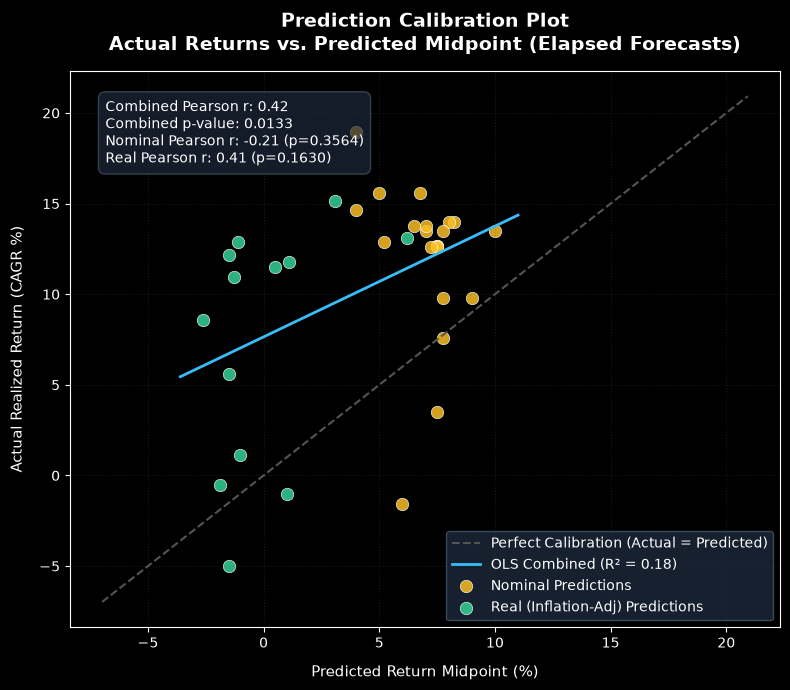

In [6]:
# Generate Calibration Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 7))

# Diagonal 1:1 perfect calibration line
min_val = min(predicted.min(), actual.min()) - 2
max_val = max(predicted.max(), actual.max()) + 2
x_diag = np.linspace(min_val, max_val, 100)
ax.plot(x_diag, x_diag, color='#555555', linestyle='--', linewidth=1.5, label='Perfect Calibration (Actual = Predicted)')

# Combined Regression line
if comb:
    x_reg = np.linspace(predicted.min() - 1, predicted.max() + 1, 100)
    y_reg = comb['slope'] * x_reg + comb['intercept']
    ax.plot(x_reg, y_reg, color='#38bdf8', linestyle='-', linewidth=2, label=f'OLS Combined (R² = {comb["r_squared"]:.2f})')

# Scatter points colored by return type
nominal_mask = df['Return Type'] == 'nominal'
ax.scatter(df.loc[nominal_mask, 'Predicted Midpoint (%)'], df.loc[nominal_mask, 'Actual Return (CAGR %)'], 
           color='#fbbf24', s=80, alpha=0.85, edgecolors='white', linewidths=0.5, label='Nominal Predictions')
ax.scatter(df.loc[~nominal_mask, 'Predicted Midpoint (%)'], df.loc[~nominal_mask, 'Actual Return (CAGR %)'], 
           color='#34d399', s=80, alpha=0.85, edgecolors='white', linewidths=0.5, label='Real (Inflation-Adj) Predictions')

# Labels and details
ax.set_title('Prediction Calibration Plot\nActual Returns vs. Predicted Midpoint (Elapsed Forecasts)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Return Midpoint (%)', fontsize=11, labelpad=10)
ax.set_ylabel('Actual Realized Return (CAGR %)', fontsize=11, labelpad=10)

# Display statistics box
if comb and nom and real:
    stats_text = (
        f"Combined Pearson r: {comb['r']:.2f}\n"
        f"Combined p-value: {comb['p']:.4f}\n"
        f"Nominal Pearson r: {nom['r']:.2f} (p={nom['p']:.4f})\n"
        f"Real Pearson r: {real['r']:.2f} (p={real['p']:.4f})"
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#1e293b', alpha=0.7, edgecolor='#475569'))

ax.legend(loc='lower right', frameon=True, facecolor='#1e293b', edgecolor='#475569')
ax.grid(True, linestyle=':', alpha=0.3, color='#475569')

plt.tight_layout()
plt.show()

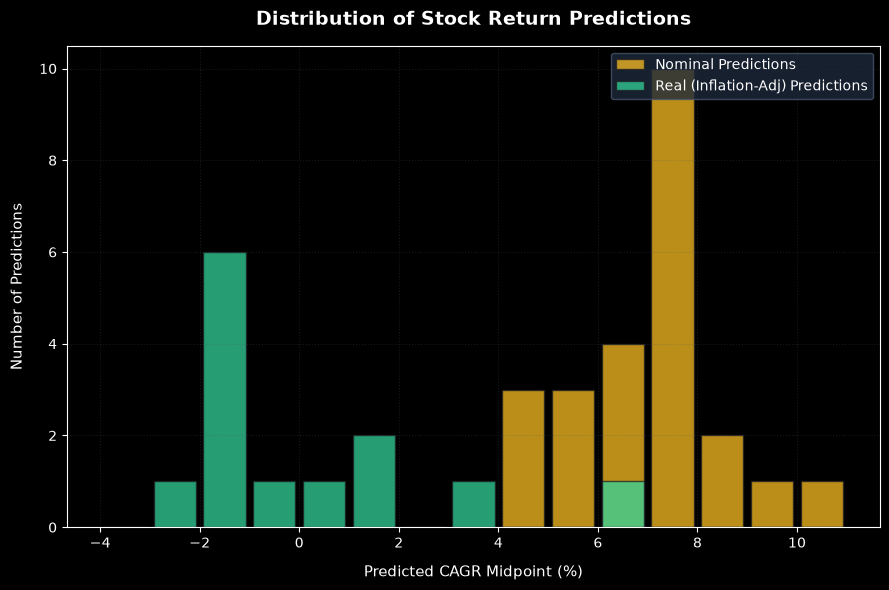

In [7]:
# Generate Distribution Histogram
plt.style.use('dark_background')
fig_hist, ax_hist = plt.subplots(figsize=(9, 6))

all_nominal_mids = [sum(p['predicted_range']) / 2.0 for p in data if p['return_type'] == 'nominal']
all_real_mids = [sum(p['predicted_range']) / 2.0 for p in data if p['return_type'] == 'real']

all_mids = all_nominal_mids + all_real_mids
min_bin = math.floor(min(all_mids)) - 1
max_bin = math.ceil(max(all_mids)) + 2
bins = np.arange(min_bin, max_bin, 1)

ax_hist.hist(all_nominal_mids, bins=bins, alpha=0.75, color='#fbbf24', edgecolor='#1e1e24', label='Nominal Predictions', rwidth=0.85)
ax_hist.hist(all_real_mids, bins=bins, alpha=0.75, color='#34d399', edgecolor='#1e1e24', label='Real (Inflation-Adj) Predictions', rwidth=0.85)

ax_hist.set_title('Distribution of Stock Return Predictions', fontsize=14, fontweight='bold', pad=15)
ax_hist.set_xlabel('Predicted CAGR Midpoint (%)', fontsize=11, labelpad=10)
ax_hist.set_ylabel('Number of Predictions', fontsize=11, labelpad=10)
ax_hist.legend(loc='upper right', frameon=True, facecolor='#1e293b', edgecolor='#475569')
ax_hist.grid(True, linestyle=':', alpha=0.3, color='#475569')

plt.tight_layout()
plt.show()

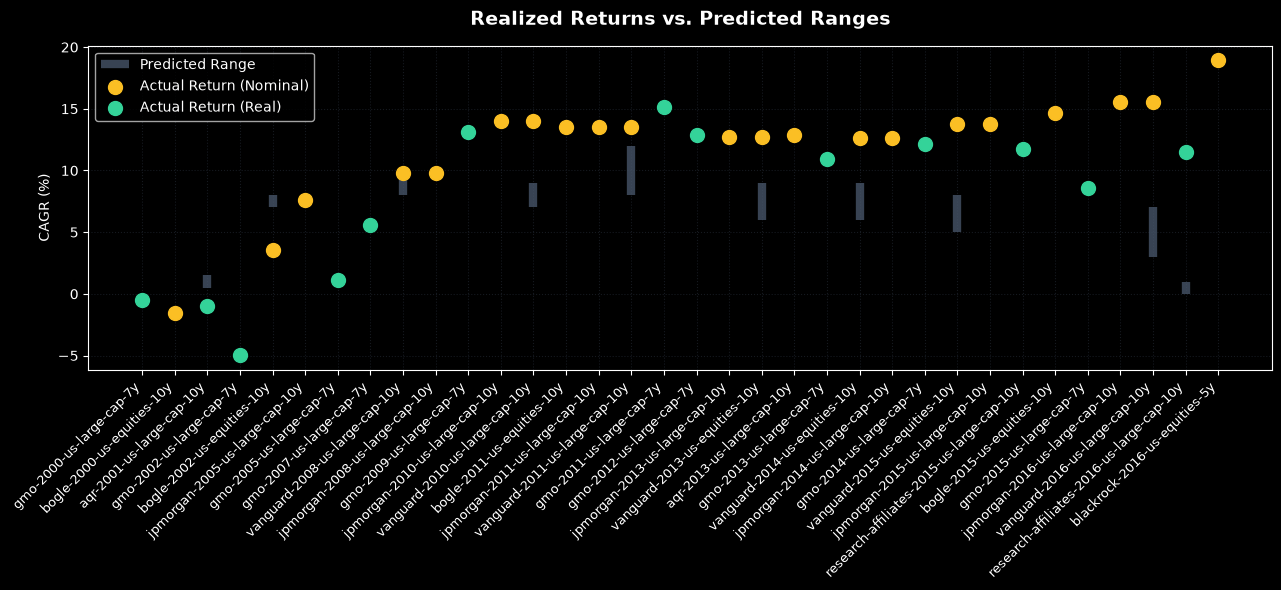

In [8]:
# Generate actual vs predicted ranges comparison bar chart
fig, ax = plt.subplots(figsize=(13, 6))

ids = df['Prediction ID']
x = np.arange(len(ids))

# Plot predicted range as vertical grey bars
for i, p_id in enumerate(ids):
    p_data = [p for p in elapsed if p['id'] == p_id][0]
    ax.vlines(i, p_data['predicted_range'][0], p_data['predicted_range'][1], 
              color='#475569', linewidth=6, alpha=0.8, label='Predicted Range' if i == 0 else "")

# Plot actual return as colored points
ax.scatter(x[nominal_mask], df.loc[nominal_mask, 'Actual Return (CAGR %)'], 
           color='#fbbf24', s=100, zorder=5, label='Actual Return (Nominal)')
ax.scatter(x[~nominal_mask], df.loc[~nominal_mask, 'Actual Return (CAGR %)'], 
           color='#34d399', s=100, zorder=5, label='Actual Return (Real)')

ax.set_title('Realized Returns vs. Predicted Ranges', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(ids, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('CAGR (%)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.3, color='#475569')
plt.tight_layout()
plt.show()

## 📝 Key Findings and Conclusions
1. **The Combined View Illusion**: Combining nominal and real return forecasts in a single correlation model yields a statistically significant positive relationship (\(r = 0.4205\), \(p = 0.0133\)). However, this is largely a mathematical illusion created by mixing two different return scales (nominal and inflation-adjusted).
2. **Wall Street Nominal Forecasts Have Zero Signal**: When isolated, nominal predictions show a slightly negative correlation of **-0.2119** with a high \(p\)-value of **0.3564**. This indicates no statistically significant relationship—meaning Wall Street's nominal return forecasts are indistinguishable from random noise.
3. **Real Forecasts Carry Directional Signal**: Real predictions show a moderate positive correlation (\(r = 0.4110\)), although the small sample size (\(n = 13\)) makes it not yet statistically significant (\(p = 0.1630\)).
4. **The Herd Mentality (Clustering)**: The distribution histogram confirms that nominal return forecasts are clustered extremely tightly in the **4.0% to 8.0% range** (with most centered at 5.0% to 7.0%). This reflects a systemic conservatism bias, where asset managers choose the safety of peer consensus over bold forecasting.
